# Causal vs. Predictive Churn Model


## Section 1: Imports & Configuration

In [34]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    "SEED":                  4,
    "N_CUSTOMERS":           1000,   # customers per simulation cycle
    "N_HISTORY":             5000,   # customers in initial training batch

    # Causal effect sizes (log-odds scale)
    "SATISFACTION_EFFECT":  -0.6,   # higher satisfaction → less churn
    "TREATMENT_EFFECT":     -1.8,   # treatment reduces churn
    "BASE_CHURN_LOGIT":      0.5,   # baseline churn intercept

    # Historical data: treatment assigned randomly (like an A/B test)
    "HISTORICAL_TREAT_RATE": 0.3,

    # Deployment decision thresholds (for you to tune)
    "PREDICTIVE_THRESHOLD":  0.5,  # treat if P(churn) >= this
    "UPLIFT_THRESHOLD":     -0.05,  # treat if estimated uplift <= this

    "SIM_CYCLES":            52,
    "EPSILON":               0.05,  # random exploration rate (prevents data collapse)

    # Adding windows to train only on recent data
    "WINDOW_CYCLES": 52,
}

np.random.seed(CONFIG["SEED"])


## Data Generating Process

In [11]:
# Reused from supervisor's notebook (simplified)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def generate_customers(n, treat_rate=None, treatment_array=None):
    """
    Generates n customers.

    Parameters
    ----------
    n               : number of customers
    treat_rate      : if set, randomly assigns treatment at this rate
    treatment_array : if set, uses this array as treatment assignments directly

    Returns
    -------
    DataFrame with columns:
        satisfaction  — independent variable (0–10), measured as NPS of customers
        treatment     — binary
        churn         — binary outcome
        p_churn       — true churn probability (ground truth)
        tau_true      — true individual treatment effect (hidden from models)
    """
    satisfaction = np.clip(np.random.normal(5, 2, n), 0, 10)

    if treatment_array is not None:
        treatment = treatment_array.astype(int)
    elif treat_rate is not None:
        treatment = np.random.binomial(1, treat_rate, n)
    else:
        treatment = np.zeros(n, dtype=int)

    logit_churn = (
        CONFIG["BASE_CHURN_LOGIT"]
        + CONFIG["SATISFACTION_EFFECT"] * satisfaction
        + CONFIG["TREATMENT_EFFECT"] * treatment
    )
    p_churn = sigmoid(logit_churn)
    churn = np.random.binomial(1, p_churn)

    # True treatment effect per customer (counterfactual — unobservable in practice)
    p_if_treated   = sigmoid(CONFIG["BASE_CHURN_LOGIT"] + CONFIG["SATISFACTION_EFFECT"] * satisfaction + CONFIG["TREATMENT_EFFECT"])
    p_if_untreated = sigmoid(CONFIG["BASE_CHURN_LOGIT"] + CONFIG["SATISFACTION_EFFECT"] * satisfaction)
    tau_true = p_if_treated - p_if_untreated  # negative = treatment reduces churn

    return pd.DataFrame({
        "satisfaction": satisfaction,
        "treatment":    treatment,
        "churn":        churn,
        "p_churn":      p_churn,
        "tau_true":     tau_true,
    })


# Sanity check
test_df = generate_customers(10000, treat_rate=CONFIG["HISTORICAL_TREAT_RATE"])
print(f"Overall churn rate:     {test_df.churn.mean():.1%}")
print(f"Untreated churn rate:   {test_df[test_df.treatment==0].churn.mean():.1%}")
print(f"Treated churn rate:     {test_df[test_df.treatment==1].churn.mean():.1%}")
print(f"Avg tau_true:           {test_df.tau_true.mean():.3f}  (negative = treatment helps)")

Overall churn rate:     8.9%
Untreated churn rate:   11.9%
Treated churn rate:     2.4%
Avg tau_true:           -0.092  (negative = treatment helps)


## Section 3: Initial Training Data

In [12]:
initial_data = generate_customers(
    CONFIG["N_HISTORY"],
    treat_rate=CONFIG["HISTORICAL_TREAT_RATE"]
)

initial_data['cycle'] = 0

print(f"Training set size:      {len(initial_data):,}")
print(f"Churn rate:             {initial_data.churn.mean():.1%}")
print(f"Treatment rate:         {initial_data.treatment.mean():.1%}")

Training set size:      5,000
Churn rate:             9.5%
Treatment rate:         29.7%


In [13]:
initial_data

,satisfaction,treatment,churn,p_churn,tau_true,cycle
0,5.755849,1,0,0.008548,-0.041023,0
1,10.000000,1,0,0.000675,-0.003395,0
2,3.614036,0,1,0.158635,-0.128411,0
3,7.396918,1,0,0.003210,-0.015901,0
4,4.672377,0,0,0.090840,-0.074592,0
...,...,...,...,...,...,...
4995,7.587814,0,0,0.017079,-0.014215,0
4996,4.830818,0,0,0.083288,-0.068492,0
4997,4.367434,0,0,0.107124,-0.087678,0
4998,2.742481,0,1,0.241314,-0.191364,0



## Training the models

In [14]:
# training the models
def train_predictive_model(df):
    X = df[['satisfaction', 'treatment']]
    y = df['churn']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=CONFIG['SEED'])

    predictive_model = LogisticRegression()

    predictive_model.fit(X_train, y = y_train)

    f1 = f1_score(y_test, predictive_model.predict(X_test))

    return {'model' : predictive_model, 'f1_score' : f1}

def train_causal_model(df):
    df_1 = df[df['treatment'] == 1]
    df_0 = df[df['treatment'] == 0]

    X_1 = df_1[['satisfaction']]
    y_1 = df_1['churn']

    X_0 = df_0[['satisfaction']]
    y_0 = df_0['churn']

    X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size = 0.25, random_state=CONFIG['SEED'])
    X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(X_0, y_0, test_size = 0.25, random_state=CONFIG['SEED'])

    m1 = LogisticRegression()
    m0 = LogisticRegression()

    m1.fit(X_train_1, y_train_1)
    m0.fit(X_train_0, y_train_0)

    # Calculating predictions
    preds = np.concatenate([m1.predict(X_test_1),
                           m0.predict(X_test_0)])
    
    y_true = np.concatenate([y_test_1, y_test_0])

    f1 = f1_score(y_true, preds)

    return {'m1' : m1, 'm0' : m0, 'f1_score' : f1}

def predict_uplift(m1, m0, X):
    p1 = m1.predict_proba(X)[:,1]
    p0 = m0.predict_proba(X)[:,1]
    
    return p1 - p0



## The deployment loop 

In [36]:
metrics = []

# Copying initial dataset to keep seperate across policies 
initial_data_pred = initial_data.copy()
initial_data_causal = initial_data.copy()

# Training the models on the initial data
predicitve_model = train_predictive_model(initial_data_pred)
causal_model = train_causal_model(initial_data_causal)

for cycle in range(1, CONFIG["SIM_CYCLES"] + 1):
    new_customers = generate_customers(CONFIG['N_CUSTOMERS'])
    X_score = new_customers[["satisfaction"]]

    # ---Predictive model: Deciding whom to treat---
    X_score_pred = pd.DataFrame({"satisfaction": new_customers["satisfaction"], "treatment": 0})
    pred_churn_prob = predicitve_model['model'].predict_proba(X_score_pred)[:,1]
    pred_treat = (pred_churn_prob >= CONFIG['PREDICTIVE_THRESHOLD']).astype(int)

    # Epsilon-greedy: randomly treat a small fraction to avoid data starvation
    explore_mask = np.random.rand(len(new_customers)) < CONFIG["EPSILON"]
    pred_treat = np.maximum(pred_treat, explore_mask.astype(int))

    # ---Causal model: Deciding whom to treat---
    estimated_uplift = predict_uplift(causal_model['m1'], causal_model['m0'], X_score)
    causal_treat = (estimated_uplift <= CONFIG['UPLIFT_THRESHOLD']).astype(int)

    explore_mask_c = np.random.rand(len(new_customers)) < CONFIG["EPSILON"]
    causal_treat = np.maximum(causal_treat, explore_mask_c.astype(int))

    # ---Get outcomes for each treatment decision---
    pred_observed = new_customers.copy()
    causal_observed = new_customers.copy()

    # Add in treatment decisions
    pred_observed['treatment'] = pred_treat
    causal_observed['treatment'] = causal_treat
    
    # Recomputing churn with the satisfaction scores
    def apply_treatment(df):
        logit = (
            CONFIG["BASE_CHURN_LOGIT"]
            + CONFIG["SATISFACTION_EFFECT"] * df["satisfaction"]
            + CONFIG["TREATMENT_EFFECT"] * df["treatment"]
        )
        df["churn"] = np.random.binomial(1, sigmoid(logit.values))
        return df
    
    pred_observed = apply_treatment(pred_observed)
    causal_observed = apply_treatment(causal_observed)

    pred_observed['cycle'] = cycle
    causal_observed['cycle'] = cycle

    # Add to historical data
    initial_data_pred = pd.concat([initial_data_pred, pred_observed], ignore_index=True)
    initial_data_causal = pd.concat([initial_data_causal, causal_observed], ignore_index = True)

    initial_data_pred = initial_data_pred[initial_data_pred["cycle"] > cycle - CONFIG["WINDOW_CYCLES"]]
    initial_data_causal = initial_data_causal[initial_data_causal["cycle"] > cycle - CONFIG["WINDOW_CYCLES"]]

    # How well does each policy handle the true customers that are persuadable 
    true_persuadables = (new_customers["tau_true"] <= CONFIG["UPLIFT_THRESHOLD"]).values

    def policy_f1(treat_decisions, true_persuadables):
        """F1 of targeting decisions vs. ground truth persuadables."""
        return f1_score(true_persuadables, treat_decisions, zero_division=0)
    
    predicitve_model = train_predictive_model(initial_data_pred)
    causal_model = train_causal_model(initial_data_causal)

    metrics.append({
        "cycle":              cycle,
        # Treatment rates
        "pred_treat_rate":    pred_treat.mean(),
        "causal_treat_rate":  causal_treat.mean(),
        # Churn rates under each policy
        "pred_churn_rate":    pred_observed["churn"].mean(),
        "causal_churn_rate":  causal_observed["churn"].mean(),
        # Holdout ML metric (misleading for causal!)
        "pred_f1_test":       predicitve_model["f1_score"],
        "causal_f1_test":     causal_model["f1_score"],
        # Business metric: are we targeting the right people?
        "pred_policy_f1":     policy_f1(pred_treat, true_persuadables),
        "causal_policy_f1":   policy_f1(causal_treat, true_persuadables),
        # Training data composition
        "pred_train_treat_rate":   initial_data_pred["treatment"].mean(),
        "causal_train_treat_rate": initial_data_causal["treatment"].mean(),
        "pred_train_churn_rate":   initial_data_pred["churn"].mean(),
        "causal_train_churn_rate": initial_data_causal["churn"].mean(),
    })

    print(f"  Cycle {cycle:2d}/{CONFIG['SIM_CYCLES']}  "
          f"| Pred churn: {pred_observed['churn'].mean():.1%}  "
          f"| Causal churn: {causal_observed['churn'].mean():.1%}  "
          f"| Pred policy F1: {metrics[-1]['pred_policy_f1']:.3f}  "
          f"| Causal policy F1: {metrics[-1]['causal_policy_f1']:.3f}")

df_metrics = pd.DataFrame(metrics)
print("\nSimulation complete.")


  Cycle  1/52  | Pred churn: 10.8%  | Causal churn: 3.1%  | Pred policy F1: 0.134  | Causal policy F1: 0.944
  Cycle  2/52  | Pred churn: 9.7%  | Causal churn: 2.5%  | Pred policy F1: 0.154  | Causal policy F1: 0.958
  Cycle  3/52  | Pred churn: 11.4%  | Causal churn: 4.5%  | Pred policy F1: 0.155  | Causal policy F1: 0.977
  Cycle  4/52  | Pred churn: 11.7%  | Causal churn: 3.5%  | Pred policy F1: 0.152  | Causal policy F1: 0.971
  Cycle  5/52  | Pred churn: 10.4%  | Causal churn: 5.6%  | Pred policy F1: 0.173  | Causal policy F1: 0.979
  Cycle  6/52  | Pred churn: 11.0%  | Causal churn: 4.5%  | Pred policy F1: 0.167  | Causal policy F1: 0.939
  Cycle  7/52  | Pred churn: 10.1%  | Causal churn: 2.9%  | Pred policy F1: 0.140  | Causal policy F1: 0.918
  Cycle  8/52  | Pred churn: 10.3%  | Causal churn: 4.0%  | Pred policy F1: 0.143  | Causal policy F1: 0.965
  Cycle  9/52  | Pred churn: 11.0%  | Causal churn: 4.0%  | Pred policy F1: 0.145  | Causal policy F1: 0.964
  Cycle 10/52  | Pre


## Visaulizing the results

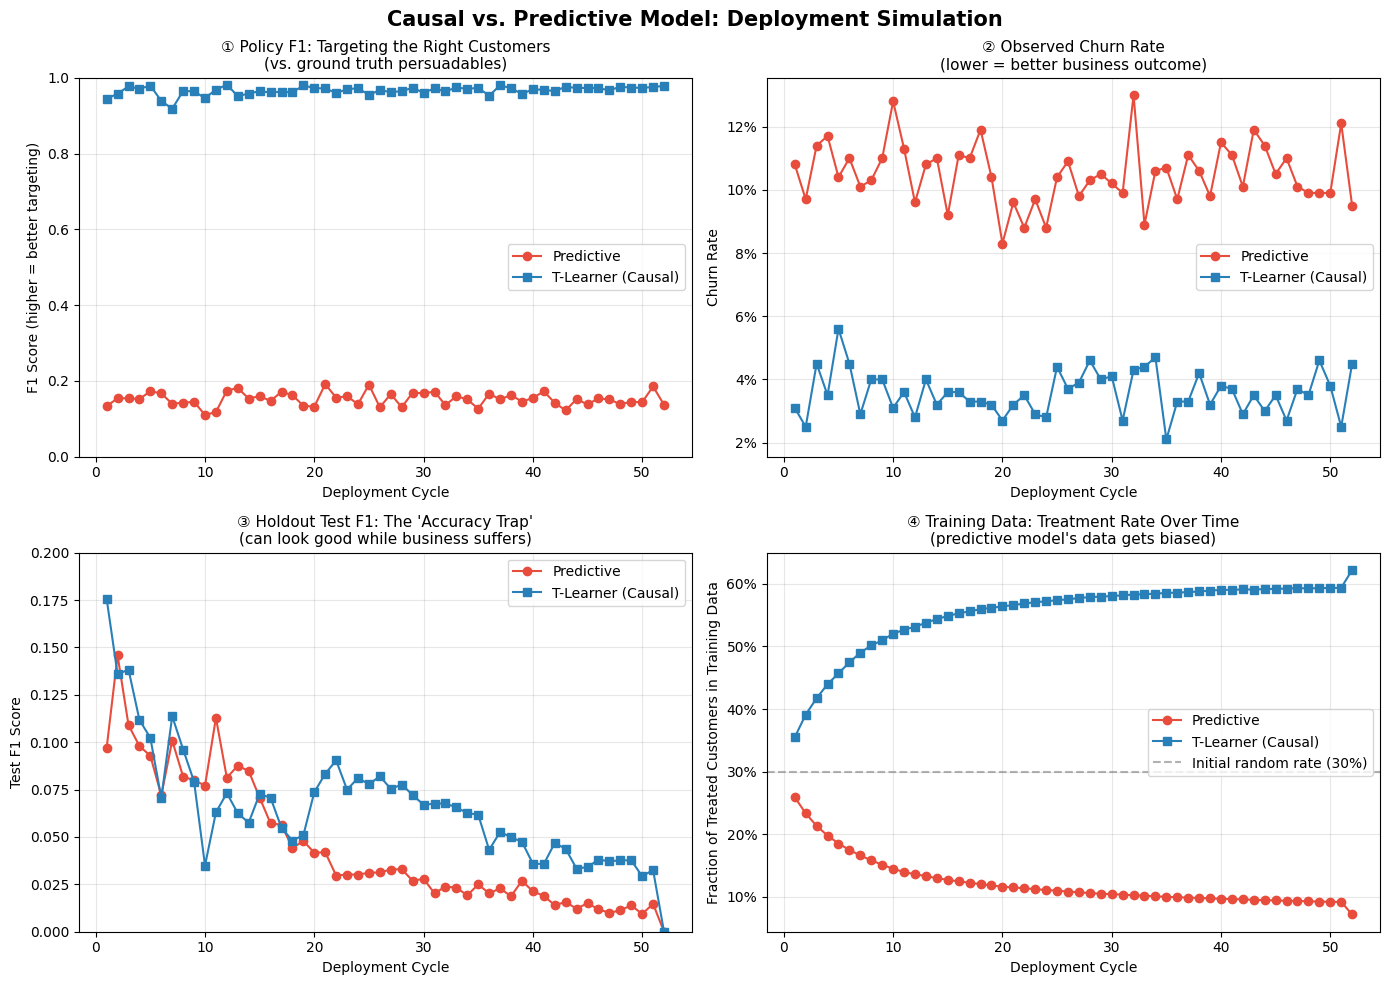

In [38]:
df_metrics = pd.DataFrame(metrics)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Causal vs. Predictive Model: Deployment Simulation", fontsize=15, fontweight="bold")

cycles = df_metrics["cycle"]
RED, BLUE = "#e74c3c", "#2980b9"

# Plot 1: Policy F1
ax = axs[0, 0]
ax.plot(cycles, df_metrics["pred_policy_f1"],   color=RED,  marker="o", label="Predictive")
ax.plot(cycles, df_metrics["causal_policy_f1"], color=BLUE, marker="s", label="T-Learner (Causal)")
ax.set_title("① Policy F1: Targeting the Right Customers\n(vs. ground truth persuadables)", fontsize=11)
ax.set_ylabel("F1 Score (higher = better targeting)")
ax.set_xlabel("Deployment Cycle")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# Plot 2: Churn rate
ax = axs[0, 1]
ax.plot(cycles, df_metrics["pred_churn_rate"],   color=RED,  marker="o", label="Predictive")
ax.plot(cycles, df_metrics["causal_churn_rate"], color=BLUE, marker="s", label="T-Learner (Causal)")
ax.set_title("② Observed Churn Rate\n(lower = better business outcome)", fontsize=11)
ax.set_ylabel("Churn Rate")
ax.set_xlabel("Deployment Cycle")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Holdout Test F1
ax = axs[1, 0]
ax.plot(cycles, df_metrics["pred_f1_test"],   color=RED,  marker="o", label="Predictive")
ax.plot(cycles, df_metrics["causal_f1_test"], color=BLUE, marker="s", label="T-Learner (Causal)")
ax.set_title("③ Holdout Test F1: The 'Accuracy Trap'\n(can look good while business suffers)", fontsize=11)
ax.set_ylabel("Test F1 Score")
ax.set_xlabel("Deployment Cycle")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.2)

# Plot 4: Training data treatment rate
ax = axs[1, 1]
ax.plot(cycles, df_metrics["pred_train_treat_rate"],   color=RED,  marker="o", label="Predictive")
ax.plot(cycles, df_metrics["causal_train_treat_rate"], color=BLUE, marker="s", label="T-Learner (Causal)")
ax.axhline(CONFIG["HISTORICAL_TREAT_RATE"], color="gray", linestyle="--", alpha=0.6,
           label=f"Initial random rate ({CONFIG['HISTORICAL_TREAT_RATE']:.0%})")
ax.set_title("④ Training Data: Treatment Rate Over Time\n(predictive model's data gets biased)", fontsize=11)
ax.set_ylabel("Fraction of Treated Customers in Training Data")
ax.set_xlabel("Deployment Cycle")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()